In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from scipy.stats import uniform, loguniform

from sklearn.model_selection import PredefinedSplit, RandomizedSearchCV, train_test_split
from sklearn.metrics import make_scorer, brier_score_loss
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss
from scipy.stats import uniform
import os
import xgboost as xgb


In [2]:
# Assume root directory is './TrainingData'
root_dir = './TrainingData'

TRAIN_list = []
LABELS_list = []
fold_indices = []

SALE_COLUMNS = ["Actual Loss Calculation", "Zero Balance Removal UPB", "Net Sales Proceeds", 
                "Delinquent Accrued Interest", "Expenses", "MI Recoveries", "Non MI Recoveries"]

MISC_COLUMNS_TO_DROP = ["MSA", 'Postal Code',  'Monthly Reporting Period',
                        'Distress Date', 'Default Flag', 'Zero Balance Code', 'Unresolved', 'Last Time Current',
                         'Property State', 'Current Loan Delinquency Status', 'Loan Sequence Number']
CAT_COLUMNS = []

fold = 0 

# Load in all files from TrainingData Folder
for year_folder in sorted(os.listdir(root_dir)):
    year_path = os.path.join(root_dir, year_folder)
    if os.path.isdir(year_path):
        for file in os.listdir(year_path):
            if file.endswith('.parquet'):
                file_path = os.path.join(year_path, file)
                df = pd.read_parquet(file_path)
                TRAIN_list.append(df.drop(columns=['Major Stress'])) 
                LABELS_list.append(df['Major Stress'])               
                fold_indices.extend([fold] * len(df))
        fold += 1

TRAIN = pd.concat(TRAIN_list).reset_index(drop=True)
TRAIN = TRAIN.drop(columns=SALE_COLUMNS)


C:\Users\seanv\AppData\Local\Temp\ipykernel_12576\454770383.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  TRAIN = pd.concat(TRAIN_list).reset_index(drop=True)


In [3]:
TRAIN = TRAIN.drop(columns=MISC_COLUMNS_TO_DROP)
categorical_cols = TRAIN.select_dtypes(include=['object', 'category']).columns.tolist()

# Use below to add columns that we want dummies for but may not current be dtype categorical
# categorical_cols += CAT_COLUMNS

TRAIN = pd.get_dummies(TRAIN, columns=categorical_cols, drop_first=True)
LABELS = pd.concat(LABELS_list).reset_index(drop=True)
LABELS.fillna(0, inplace=True)

ps = PredefinedSplit(test_fold=fold_indices)

### How to Wrap XGB in a SKL Grid Search CVC
Scorer should be something like Brier Score or F1 (needs to account for the ridiculous imabalance and also should make sure probabilities are well calibrated)

In [4]:
def calibration_errors_adaptive(y_true, y_prob, min_bin_size=200):
    """
    Calculate ECE and MCE with adaptive binning:
    - min_bin_size controls minimum number of samples per bin
    - automatically determines number of bins based on data size
    """
    import numpy as np

    n_samples = len(y_true)
    n_bins = max(1, n_samples // min_bin_size)

    # Edge case: cap at reasonable number of bins
    n_bins = min(n_bins, 20)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1

    ece = 0.0
    mce = 0.0

    for i in range(n_bins):
        bin_mask = binids == i
        bin_size = np.sum(bin_mask)

        if bin_size > 0:
            bin_prob_mean = np.mean(y_prob[bin_mask])
            bin_true_mean = np.mean(y_true[bin_mask])
            error = abs(bin_prob_mean - bin_true_mean)

            ece += (bin_size / n_samples) * error
            mce = max(mce, error)

    return ece, mce

from sklearn.metrics import make_scorer

def ece_scorer(y_true, y_pred_prob):
    ece, _ = calibration_errors_adaptive(y_true, y_pred_prob)
    return -ece  # negate because sklearn expects "higher is better" for scores



In [5]:
state = 40

# First split: TRAIN into Training+EarlyStopping and Final Validation sets
X_full_train, X_val, y_full_train, y_val = train_test_split(
    TRAIN, LABELS, test_size=0.2, random_state=state, stratify=LABELS
)

# Second split: split Training+EarlyStopping into Training and EarlyStopping
X_train, X_early_stop, y_train, y_early_stop = train_test_split(
    X_full_train, y_full_train, test_size=0.2, random_state=state, stratify=y_full_train
)

print(f"Train shape: {X_train.shape}, Early Stopping shape: {X_early_stop.shape}, Validation shape: {X_val.shape}")


Train shape: (3701891, 46), Early Stopping shape: (925473, 46), Validation shape: (1156841, 46)


In [6]:
state = 40
# Step 1: Sample 500,000 rows stratified by LABELS
subset_size = 1_000_000
X_sub, _, y_sub, _ = train_test_split(
    TRAIN, LABELS, 
    train_size=subset_size, 
    stratify=LABELS, 
    random_state=state
)

# Step 2: Split into train, early stop, validation (60/20/20 split)
X_train_sub, X_holdout_sub, y_train_sub, y_holdout_sub = train_test_split(
    X_sub, y_sub, test_size=0.4, stratify=y_sub, random_state=state
)
X_early_stop_sub, X_val_sub, y_early_stop_sub, y_val_sub = train_test_split(
    X_holdout_sub, y_holdout_sub, test_size=0.5, stratify=y_holdout_sub, random_state=state
)


In [8]:
NumParamSearchIterations = 15
# Expanded hyperparameter search space
param_distributions = {
    'n_estimators': range(100, 600), 
    'learning_rate': uniform(0.005, 0.05),  
    'max_depth': range(4, 15),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'scale_pos_weight': range(60, 150)  
}

# Setup RandomizedSearchCV
hyperparameter_tuning = RandomizedSearchCV(
    xgb.XGBClassifier(
        random_state=state,
        objective='binary:logistic',
        early_stopping_rounds=20,
        use_label_encoder=False,
        n_jobs = 2
    ),
    scoring="neg_brier_score", 
    param_distributions=param_distributions,
    n_iter=NumParamSearchIterations,
    cv=3,
    random_state=state,
    verbose=2,
    n_jobs=3
)

search = hyperparameter_tuning.fit(
    X_train_sub, y_train_sub,
    eval_set=[(X_early_stop_sub, y_early_stop_sub)],
    verbose=True
)


# Output best results
print("\nBest Hyperparameters:", search.best_params_)
print("Best Brier Score (negated):", search.best_score_)

# Extract best model
best_model = search.best_estimator_

# Final validation predictions on untouched validation set
y_val_pred_probs = best_model.predict_proba(X_val_sub)[:, 1]

# Standard metrics
ap_score = average_precision_score(y_val_sub, y_val_pred_probs)
brier = brier_score_loss(y_val_sub, y_val_pred_probs)
logloss = log_loss(y_val_sub, y_val_pred_probs)

# New calibration metrics
ece, mce = calibration_errors_adaptive(y_val_sub, y_val_pred_probs)

print("\nValidation Metrics:")
print(f"Average Precision Score: {ap_score:.4f}")
print(f"Brier Score: {brier:.6f}")
print(f"Log Loss: {logloss:.6f}")
print(f"Expected Calibration Error (ECE): {ece:.6f}")
print(f"Maximum Calibration Error (MCE): {mce:.6f}")


Fitting 3 folds for each of 15 candidates, totalling 45 fits


c:\Users\seanv\Anaconda3_old\envs\gpt-env\lib\site-packages\xgboost\core.py:158: UserWarning: [16:20:15] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[0]	validation_0-logloss:0.58217
[1]	validation_0-logloss:0.55830
[2]	validation_0-logloss:0.53565
[3]	validation_0-logloss:0.51465
[4]	validation_0-logloss:0.49514
[5]	validation_0-logloss:0.47690
[6]	validation_0-logloss:0.45963
[7]	validation_0-logloss:0.44377
[8]	validation_0-logloss:0.42879
[9]	validation_0-logloss:0.41441
[10]	validation_0-logloss:0.40116
[11]	validation_0-logloss:0.38888
[12]	validation_0-logloss:0.37726
[13]	validation_0-logloss:0.36639
[14]	validation_0-logloss:0.35595
[15]	validation_0-logloss:0.34603
[16]	validation_0-logloss:0.33666
[17]	validation_0-logloss:0.32790
[18]	validation_0-logloss:0.31958
[19]	validation_0-logloss:0.31160
[20]	validation_0-logloss:0.30383
[21]	validation_0-logloss:0.29666
[22]	validation_0-logloss:0.28994
[23]	validation_0-logloss:0.28305
[24]	validation_0-logloss:0.27676
[25]	validation_0-logloss:0.27065
[26]	validation_0-logloss:0.26486
[27]	validation_0-logloss:0.25959
[28]	validation_0-logloss:0.25437
[29]	validation_0-loglos

In [10]:
import pandas as pd

results_df = pd.DataFrame({
    'y_true': y_val_sub,
    'y_pred_prob': y_val_pred_probs
})

# Define probability bins
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
labels = ['0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5', 
          '0.5-0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']
results_df['prob_bin'] = pd.cut(results_df['y_pred_prob'], bins=bins, labels=labels, include_lowest=True)

# Group by bins
bin_summary = results_df.groupby('prob_bin').agg(
    samples=('y_true', 'count'),
    percent=('y_true', lambda x: len(x) / len(results_df) * 100),
    distress_rate=('y_true', 'mean')
).reset_index()


print(bin_summary)


  prob_bin  samples  percent  distress_rate
0    0-0.1   194122  97.0610       0.003683
1  0.1-0.2     2481   1.2405       0.049174
2  0.2-0.3     1029   0.5145       0.059281
3  0.3-0.4      479   0.2395       0.093946
4  0.4-0.5      344   0.1720       0.154070
5  0.5-0.6      252   0.1260       0.146825
6  0.6-0.7      191   0.0955       0.235602
7  0.7-0.8      172   0.0860       0.313953
8  0.8-0.9      178   0.0890       0.443820
9  0.9-1.0      752   0.3760       0.704787


C:\Users\seanv\AppData\Local\Temp\ipykernel_35112\1847273224.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_summary = results_df.groupby('prob_bin').agg(


In [ ]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# Compute calibration curve
# (true labels, predicted probabilities, and number of bins)
true_probs, pred_probs = calibration_curve(y_val, y_val_pred_probs, n_bins=10, strategy='uniform')

# Plot
plt.figure(figsize=(6, 6))
plt.plot(pred_probs, true_probs, marker='o', linewidth=2, label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.title('Calibration Curve (Validation Set)')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.grid(True)
plt.show()


In [14]:
import pandas as pd

# Pull feature importance scores
booster = best_model.get_booster()
importance_dict = booster.get_score(importance_type='gain')

# Convert to DataFrame for easy viewing
importance_df = pd.DataFrame({
    'Feature': list(importance_dict.keys()),
    'Importance (Gain)': list(importance_dict.values())
}).sort_values(by='Importance (Gain)', ascending=False)

print(importance_df)


                                        Feature  Importance (Gain)
21                          Numeric Delinquency         643.090759
22                          MaxPriorDelinquency          99.701019
9                           Number of Borrowers          69.668617
25                                 HPI Change %          67.696877
38                          Program Indicator_F          65.938095
10                    Property Valuation Method          58.449940
33                             Property Type_MH          49.832592
6                  Original Loan-to-Value (LTV)          48.820164
28                  First Time Homebuyer Flag_Y          45.371613
2                               Number of Units          45.309113
18               Estimated Loan-to-Value (ELTV)          45.169907
0                                  Credit Score          45.035046
32                             Property Type_CP          44.846622
37                               Loan Purpose_P          40.04

## Ensemble

In [6]:
# Best Hyper Params
best_params = {
               'colsample_bytree': 0.9872197327257972, 
               'learning_rate': 0.046666662536206674, 
               'max_depth': 11, 
               'n_estimators': 527, 
               'scale_pos_weight': 95, 
               'subsample': 0.9286871422830952
               }


n_models = 1
seeds = np.arange(60, 60 + n_models)
models = []
for seed in seeds:
    model = xgb.XGBClassifier(**best_params, random_state=seed, early_stopping_rounds=50)
    model.fit(
        X_train, y_train,
        eval_set=[(X_early_stop, y_early_stop)],
        verbose=False
    )
    models.append(model)

# Predict: average the probabilities across all models
all_preds = np.zeros(X_val.shape[0])

for model in models:
    preds = model.predict_proba(X_val)[:, 1]
    all_preds += preds

ensemble_preds = all_preds / n_models  

# Evaluate ensemble
ap_score = average_precision_score(y_val, ensemble_preds)
brier = brier_score_loss(y_val, ensemble_preds)
logloss = log_loss(y_val, ensemble_preds)
ece, mce = calibration_errors_adaptive(y_val, ensemble_preds)


print("\nEnsemble Validation Metrics:")
print(f"Average Precision Score: {ap_score:.4f}")
print(f"Brier Score: {brier:.6f}")
print(f"Log Loss: {logloss:.6f}")
print(f"Expected Calibration Error (ECE): {ece:.6f}")
print(f"Maximum Calibration Error (MCE): {mce:.6f}")


Ensemble Validation Metrics:
Average Precision Score: 0.4150
Brier Score: 0.028107
Log Loss: 0.107802
Expected Calibration Error (ECE): 0.069152
Maximum Calibration Error (MCE): 0.694228


In [ ]:
import joblib
import os

# Create a folder to store models if it doesn't exist
os.makedirs("ensemble_models", exist_ok=True)

# Save each model individually
for idx, model in enumerate(models):
    joblib.dump(model, f"ensemble_models/xgb_model_seed_{seeds[idx]}.joblib")

print("Ensemble models saved.")


In [7]:
# Calibration evaluation
results_df = pd.DataFrame({
    'y_true': y_val,
    'y_pred_prob': ensemble_preds
})

# Define probability bins
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
labels = ['0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5', 
          '0.5-0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']
results_df['prob_bin'] = pd.cut(results_df['y_pred_prob'], bins=bins, labels=labels, include_lowest=True)

# Group by bins
bin_summary = results_df.groupby('prob_bin').agg(
    samples=('y_true', 'count'),
    percent=('y_true', lambda x: len(x) / len(results_df) * 100),
    distress_rate=('y_true', 'mean')
).reset_index()

print("\nCalibration Summary by Probability Bin:")
print(bin_summary)



Calibration Summary by Probability Bin:
  prob_bin  samples    percent  distress_rate
0    0-0.1   927320  80.159676       0.001439
1  0.1-0.2    97590   8.435904       0.007839
2  0.2-0.3    44813   3.873739       0.012608
3  0.3-0.4    26917   2.326767       0.018501
4  0.4-0.5    17774   1.536425       0.027231
5  0.5-0.6    12977   1.121762       0.035447
6  0.6-0.7     9681   0.836848       0.052371
7  0.7-0.8     6832   0.590574       0.082406
8  0.8-0.9     5015   0.433508       0.155334
9  0.9-1.0     7922   0.684796       0.519818


C:\Users\seanv\AppData\Local\Temp\ipykernel_12576\615897617.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_summary = results_df.groupby('prob_bin').agg(


In [14]:
df = pd.DataFrame({
    'y_true': y_val,
    'y_prob': ensemble_preds
})
df['prob_bin'] = pd.qcut(df['y_prob'], q=1000, labels=False)

# Group by bin and calculate average predicted probability and actual event rate
calibration_df = df.groupby('prob_bin').agg(
    avg_predicted_prob=('y_prob', 'mean'),
    actual_rate=('y_true', 'mean'),
    count=('y_true', 'count')
).reset_index()

# Optional: round values for cleaner display
calibration_df = calibration_df.round(4)

In [15]:
calibration_df

,prob_bin,avg_predicted_prob,actual_rate,count
0,0,0.0000,0.0000,1157
1,1,0.0000,0.0000,1157
2,2,0.0000,0.0000,1157
3,3,0.0000,0.0000,1157
4,4,0.0000,0.0000,1157
...,...,...,...,...
995,995,0.9550,0.3846,1157
996,996,0.9729,0.4641,1157
997,997,0.9864,0.6007,1157
998,998,0.9944,0.7476,1157


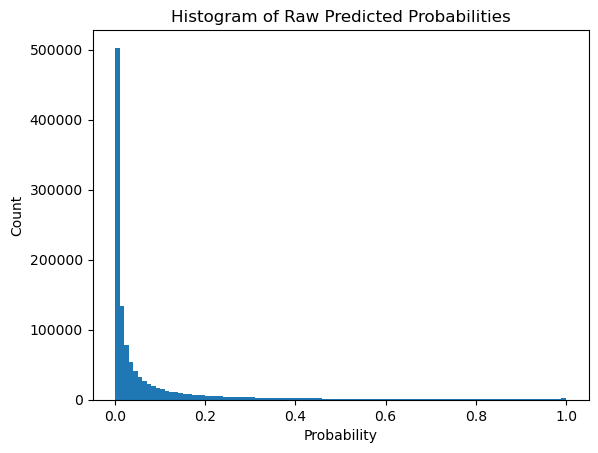

In [30]:
import matplotlib.pyplot as plt

plt.hist(ensemble_preds, bins=100)
plt.title("Histogram of Raw Predicted Probabilities")
plt.xlabel("Probability")
plt.ylabel("Count")
plt.show()
